# Comparison of Diversification Approaches — final comparison

All strategies go through the shared `backtest.rolling_backtest`, so they use the same universe,
the same single-factor covariance estimate, the same delisting and turnover conventions, and
are scored with the same metrics (`backtesting_analysis.performance_table`).

| Strategy | Constructor | Code |
|---|---|---|
| Equally weighted | `equal_weight` | `benchmarks.py` |
| Value weighted | `value_weight` | `benchmarks.py` |
| Minimum risk | `min_risk_closed_form` | `min_risk.py` |
| Risk parity | `risk_parity` | `risk_parity.py` |

| Section | Content |
|---|---|
| §1–2 | Setup, data, data-quality checks |
| §3 | Parameters and universe summary |
| §4 | Backtest of every strategy in `STRATEGIES`, alignment checks |
| §5 | Summary statistics (format of Exhibit 1, Clarke, de Silva and Thorley 2013) |
| §6 | Cumulative returns (format of Exhibit 4, Clarke, de Silva and Thorley 2006) |

**Adding a strategy:** put its constructor in `STRATEGIES` (§4) and re-run; the table and chart pick it up.

## 1. Setup

In [1]:
import os, sys, warnings
# Run from the project root whether the kernel starts there or in analysis/.
if not os.path.exists("data") and os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
sys.path.insert(0, os.getcwd())
# numpy on macOS Accelerate emits spurious matmul RuntimeWarnings; results are unaffected.
warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*encountered in matmul")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from backtest import rolling_backtest, summarize
from min_risk import min_risk_closed_form
from risk_parity import risk_parity
from benchmarks import equal_weight, value_weight
from backtesting_analysis import (returns_from_panel, performance_table,
                                  cumulative_returns, check_alignment)
from project_data import download_crsp, data_quality_report, universe_summary

pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 1.5,
})

# Same colours and names as analysis/risk_parity.ipynb
COLORS = {"min_risk": "#2a78d6", "risk_parity": "#1baf7a", "ew": "#eda100", "vw": "#e87ba4"}
LABELS = {"min_risk": "Minimum risk", "risk_parity": "Risk parity",
          "ew": "Equally weighted", "vw": "Value weighted"}

## 2. Data

* `data/crsp_msf_v2.parquet` — CRSP monthly stock file (US common stocks), 1990-01 to 2025-12.
  If the file is missing, it is downloaded from WRDS with your own account.
* `data/MktRf.csv` — market excess return and risk-free rate (Kenneth French, percentage points → divided by 100).

In [2]:
if os.path.exists("data/crsp_msf_v2.parquet"):
    raw = download_crsp()
else:
    import wrds
    raw = download_crsp(wrds.Connection())

data_quality_report(raw).to_frame("value")

Loaded data/crsp_msf_v2.parquet: (2179752, 14)


,value
rows,2179752
unique permnos,18905
first month,199001
last month,202512
"duplicate (permno, month)",0
missing mthret (%),1.8270
missing mthcap (%),1.7930
returns < -100%,0
returns > +100%,7313
returns > +300%,526


In [3]:
# Same preparation as the other notebooks: NYSE / NYSE American / Nasdaq only, keyed on yyyymm.
crsp = raw[raw.primaryexch.isin(["N", "A", "Q"])]
rets = crsp.pivot_table(index="yyyymm", columns="permno", values="mthret")
caps = crsp.pivot_table(index="yyyymm", columns="permno", values="mthcap")

ff = pd.read_csv("data/MktRf.csv", index_col=0)
mkt = (ff["Mkt-RF"] / 100.0).reindex(rets.index)
rf = (ff["RF"] / 100.0).reindex(rets.index)

assert not mkt.isna().any() and not rf.isna().any(), "MktRf does not cover the CRSP window"
assert 0.03 < mkt.std() < 0.07, "Mkt-RF units look wrong -- did you divide by 100?"
assert rets.min().min() >= -1.0, "a return below -100% is impossible"
print(f"panel {rets.shape[0]} months x {rets.shape[1]:,} stocks, {rets.index[0]}..{rets.index[-1]}")

panel 432 months x 18,898 stocks, 199001..202512


## 3. Parameters and universe summary

In [4]:
START_YEAR, END_YEAR, T, N = 1995, 2025, 60, 500

idx = rets.index
i_first = idx.get_loc(START_YEAR * 100 + 1) - 1   # last in-sample month before 1995-01
i_last = idx.get_loc(END_YEAR * 100 + 12) - 1
print(f"rebalances {idx[i_first]}..{idx[i_last]}, out-of-sample {idx[i_first + 1]}..{idx[i_last + 1]}, "
      f"{i_last - i_first + 1} months")

rebalances 199412..202511, out-of-sample 199501..202512, 372 months


In [5]:
us = universe_summary(rets, caps, T, N, start=idx[i_first], end=idx[i_last])
us.describe().T

,count,mean,std,min,25%,50%,75%,max
n_eligible,372.0000,"3,252.6478",515.8474,"2,592.0000","2,706.5000","3,130.5000","3,818.2500","4,059.0000"
n_universe,372.0000,500.0000,0.0000,500.0000,500.0000,500.0000,500.0000,500.0000
min_cap_musd,372.0000,"5,119.6468","2,689.3526","1,475.2260","2,803.8285","4,249.1475","6,763.4747","11,849.6783"
median_cap_musd,372.0000,"13,840.5208","8,117.7502","3,472.9826","7,573.1825","11,003.6787","17,964.5626","35,353.6271"
share_of_total_cap,372.0000,0.8026,0.0391,0.7114,0.7834,0.8035,0.8193,0.8943
top10_weight_vw,372.0000,0.2260,0.0489,0.1665,0.1906,0.2097,0.2452,0.4051
new_names,371.0000,12.4690,4.6523,3.0000,9.5000,11.0000,14.0000,34.0000
missing_next_ret,372.0000,1.5376,1.4889,0.0000,0.0000,1.0000,2.0000,9.0000


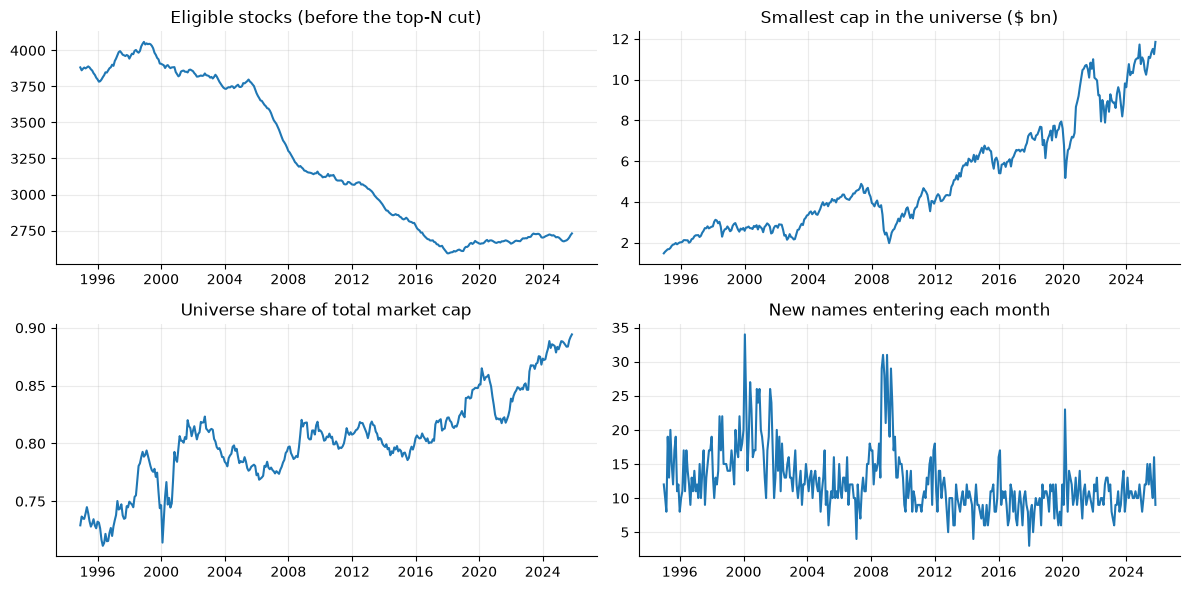

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6))
when_us = pd.PeriodIndex([str(d) for d in us.index], freq="M").to_timestamp()
ax[0, 0].plot(when_us, us.n_eligible); ax[0, 0].set_title("Eligible stocks (before the top-N cut)")
ax[0, 1].plot(when_us, us.min_cap_musd / 1e3); ax[0, 1].set_title("Smallest cap in the universe ($ bn)")
ax[1, 0].plot(when_us, us.share_of_total_cap); ax[1, 0].set_title("Universe share of total market cap")
ax[1, 1].plot(when_us, us.new_names); ax[1, 1].set_title("New names entering each month")
plt.tight_layout(); plt.show()

## 4. Backtest

One call runs every strategy on the same universe and covariance estimate each month.
`check_alignment` then confirms identical months, rebalance dates and universes, and fully
invested long-only weights.

In [7]:
STRATEGIES = {
    "ew": equal_weight,
    "vw": value_weight,
    "min_risk": min_risk_closed_form,
    "risk_parity": risk_parity,
}

panel, weights = rolling_backtest(rets, caps, mkt, rf, T=T, n=N,
                                  start=idx[i_first], end=idx[i_last],
                                  constructors=STRATEGIES)
returns = returns_from_panel(panel)[list(STRATEGIES)]

check_alignment(returns, weights, asset_returns=rets)
assert len(returns) == i_last - i_first + 1
print(f"{len(returns)} months x {returns.shape[1]} strategies; alignment checks passed")

372 months x 4 strategies; alignment checks passed


## 5. Summary statistics

Conventions (`backtesting_analysis.py`): geometric annualised return; volatility and Sharpe
ratio on **excess** returns; maximum drawdown on the compounded path; beta against the market
excess return; one-way turnover against the previous month's **drifted** weights.
The table is cross-checked against `backtest.summarize`.

In [8]:
table = performance_table(returns, weights, rf=rf, asset_returns=rets, mkt=mkt)

ref = summarize(panel)
for col in ["ann_return", "ann_vol", "sharpe", "max_drawdown", "ann_turnover"]:
    gap = np.abs(table[col] - ref.loc[table.index, col]).max()
    assert gap < 1e-12, f"{col} disagrees with backtest.summarize by {gap:.1e}"

table.rename(index=lambda k: LABELS.get(k, k))

,months,ann_return,ann_vol,sharpe,max_drawdown,cum_return,ann_turnover,beta
Equally weighted,372.0000,0.1163,0.1574,0.6313,-0.5170,29.2868,0.6166,0.9769
Value weighted,372.0000,0.1155,0.1482,0.6557,-0.4913,28.5812,0.1001,0.9437
Minimum risk,372.0000,0.0820,0.1272,0.4992,-0.3755,10.5178,1.1662,0.3395
Risk parity,372.0000,0.1162,0.1404,0.6890,-0.4890,29.2089,0.6241,0.8457


## 6. Cumulative returns

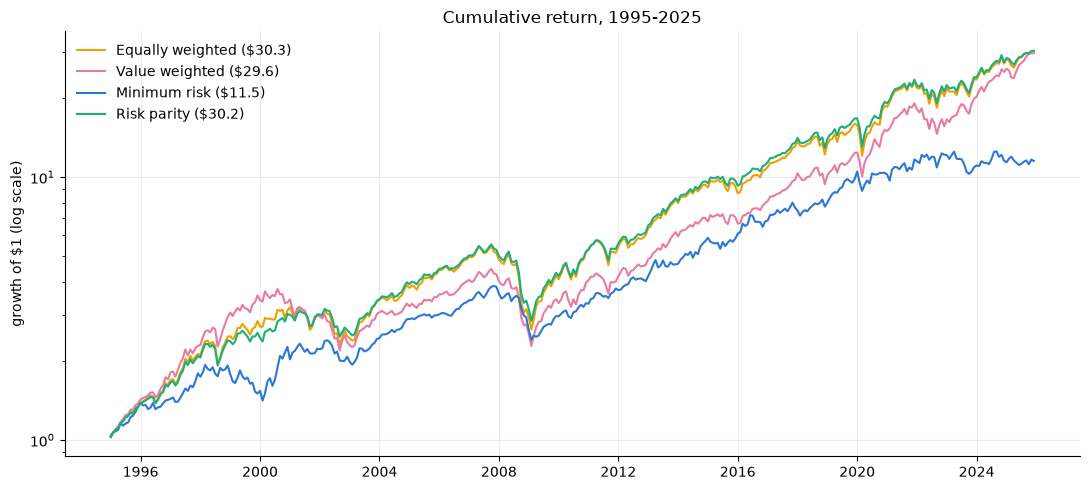

In [9]:
when = pd.PeriodIndex([str(d) for d in returns.index], freq="M").to_timestamp()
wealth = 1.0 + cumulative_returns(returns)

fig, ax = plt.subplots(figsize=(11, 5))
for k in returns.columns:
    ax.plot(when, wealth[k], color=COLORS.get(k),
            label=f"{LABELS.get(k, k)} (${wealth[k].iloc[-1]:.1f})")
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log scale)")
ax.set_title(f"Cumulative return, {START_YEAR}-{END_YEAR}")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); plt.show()